# Passive compliance — pose sweep

Effect of starting Z pose on passive compliance behavior across two virtual stiffness values.  
$K_d \in \{0.2,\, 0.6\}$ N·m/rad; three starting offsets: $+5$ mm, $0$ mm, $-5$ mm relative to `UR5_POSE`.  
Descent = 10 mm per run.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mc
import os, sys
from glob import glob

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size
FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)
plt.rcParams['savefig.bbox'] = 'tight'   # export exactly the displayed (PNG) figure

# Shared data box so all normal-force-vs-distance plots match the stiffness sweeps
AX_RECT = [0.15, 0.17, 0.68, 0.76]

OUTPUT_DIR = os.path.join('outputs', 'pose_sweep')
COLORS     = plt.rcParams['axes.prop_cycle'].by_key()['color']

KD_VALUES = [0.1, 0.6]
OFFSETS_M = [+0.005, 0.0, -0.005]


def kd_label(kd):
    return f'kd_{kd:.1f}'


def offset_label(offset_m):
    mm   = int(round(offset_m * 1000))
    sign = '+' if mm >= 0 else ''
    return f'offset_{sign}{mm}mm'


def fmt_label(offset_m):
    mm = int(round(offset_m * 1000))
    return '0 mm' if mm == 0 else f'{mm:+d} mm'


def _darken(color, factor=0.55):
    rgb = mc.to_rgb(color)
    return tuple(c * factor for c in rgb)


def color_for(kd_idx, off_idx):
    """offset → hue family, KD index → shade (0=normal, 1=darker)."""
    base = COLORS[off_idx % len(COLORS)]
    return base if kd_idx == 0 else _darken(base)


def load_runs(kd, offset_m):
    off_lbl = offset_label(offset_m)
    pattern = os.path.join(OUTPUT_DIR, kd_label(kd), off_lbl, f'{off_lbl}_run_*.csv')
    files   = sorted(glob(pattern))
    return [pd.read_csv(f) for f in files]


def interp_disp_phase(dfs, phase, col='Force_N', n_pts=500):
    """Interpolate one phase onto a common displacement grid."""
    pairs = []
    for df in dfs:
        sub = df[df['Phase'] == phase].copy() if 'Phase' in df.columns else df.copy()
        if sub.empty:
            continue
        g = (sub.groupby('UR5_displacement_m', as_index=False)[col]
               .mean()
               .sort_values('UR5_displacement_m'))
        d_arr = g['UR5_displacement_m'].to_numpy()
        f_arr = g[col].to_numpy()
        if len(d_arr) < 2:
            continue
        pairs.append((d_arr, f_arr))
    if not pairs:
        return None, None
    d_max  = min(0.01, min(d.max() for d, _ in pairs))
    d_grid = np.linspace(0, d_max, n_pts)
    vals   = np.array([np.interp(d_grid, d, f) for d, f in pairs])
    return d_grid, vals


data = {(kd, off): load_runs(kd, off) for kd in KD_VALUES for off in OFFSETS_M}
for (kd, off), runs in data.items():
    print(f'K_d={kd}  offset={fmt_label(off):>6}  ->  {len(runs)} run(s)')

K_d=0.1  offset= +5 mm  ->  5 run(s)
K_d=0.1  offset=  0 mm  ->  5 run(s)
K_d=0.1  offset= -5 mm  ->  5 run(s)
K_d=0.6  offset= +5 mm  ->  5 run(s)
K_d=0.6  offset=  0 mm  ->  5 run(s)
K_d=0.6  offset= -5 mm  ->  5 run(s)


## F vs d — all starting poses

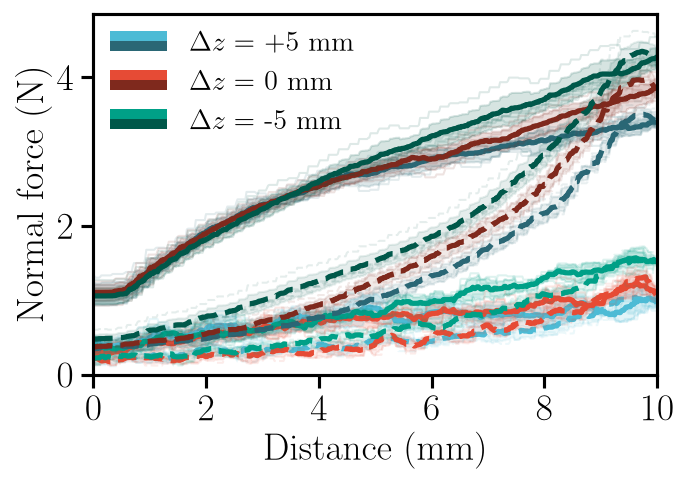

In [10]:
# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN   = 8.5 * 0.65    # figure width (inches)
ASPECT = 5.15 / 9   # height / width  ->  set to change proportions
H_IN   = W_IN * ASPECT   # figure height (inches)

fig = plt.figure(figsize=(W_IN, H_IN))
ax = fig.add_axes(AX_RECT)

phase_specs = [
    ('descent', '-',  0.13, 0.16),
    ('ascent',  '--', 0.10, 0.10),
]

for ki, kd in enumerate(KD_VALUES):
    for oi, off in enumerate(OFFSETS_M):
        runs  = data[(kd, off)]
        if not runs:
            continue
        color = color_for(ki, oi)

        for phase, ls, raw_a, band_a in phase_specs:
            d, vals = interp_disp_phase(runs, phase=phase)
            if vals is None:
                continue
            d_mm      = d * 1e3
            mean, std = vals.mean(0), vals.std(0)

            for v in vals:
                ax.plot(d_mm, v, color=color, alpha=raw_a, linewidth=1, linestyle=ls)
            ax.plot(d_mm, mean, color=color, linewidth=2.5, linestyle=ls)
            ax.fill_between(d_mm, mean - std, mean + std, color=color, alpha=band_a)

# One legend entry per offset; the swatch stacks both K_d shades of that offset's
# hue (top = K_d=0.1, bottom = K_d=0.6). K_d is annotated by hand on the curves.
from matplotlib.patches import Rectangle


class _TwoToneHandler:
    """Legend swatch split into two stacked colors (top over bottom)."""
    def __init__(self, c_top, c_bot):
        self.c_top, self.c_bot = c_top, c_bot

    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        w, h   = handlebox.width, handlebox.height
        tr  = handlebox.get_transform()
        top = Rectangle((x0, y0 + h / 2), w, h / 2, facecolor=self.c_top,
                        edgecolor='none', transform=tr)
        bot = Rectangle((x0, y0),         w, h / 2, facecolor=self.c_bot,
                        edgecolor='none', transform=tr)
        handlebox.add_artist(top)
        handlebox.add_artist(bot)
        return top


# Only one entry per offset that actually has data
legend_handles, legend_labels, handler_map = [], [], {}
for oi, off in enumerate(OFFSETS_M):
    if not any(data[(kd, off)] for kd in KD_VALUES):
        continue
    key = object()                      # placeholder handle -> custom swatch
    legend_handles.append(key)
    legend_labels.append(rf'$\Delta z =$ {fmt_label(off)}')
    handler_map[key] = _TwoToneHandler(color_for(0, oi), color_for(1, oi))

ax.set_xlabel('Distance (mm)')
ax.set_ylabel('Normal force (N)')
ax.legend(legend_handles, legend_labels, handler_map=handler_map, loc='upper left')
ax.set_xlim(0, 10)
ax.set_ylim(bottom=0)
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'F_vs_d_pose_sweep.pdf'))
plt.show()


## Effective stiffness per starting pose

Effective stiffness computed as $\Delta F / \Delta d$ over the descent phase.

In [11]:
k_eff = {}

for kd in KD_VALUES:
    for off in OFFSETS_M:
        k_runs = []
        for df in data[(kd, off)]:
            if df is None or df.empty:
                continue
            sub = df[df['Phase'] == 'descent'].copy() if 'Phase' in df.columns else df.copy()
            g   = (sub.groupby('UR5_displacement_m', as_index=False)['Force_N']
                      .mean()
                      .sort_values('UR5_displacement_m'))
            d_m = g['UR5_displacement_m'].to_numpy()
            f_n = g['Force_N'].to_numpy()
            if len(d_m) < 2:
                continue
            dd = d_m[-1] - d_m[0]
            if dd <= 0:
                continue
            k_runs.append((f_n[-1] - f_n[0]) / dd)
        k_eff[(kd, off)] = k_runs

sorted_offsets = sorted(OFFSETS_M)
print(f"{'K_d':>5}  {'Offset':>8}  {'K_eff (N/m)':>12}  {'Std (N/m)':>10}  {'N runs':>6}")
print('-' * 50)
for kd in KD_VALUES:
    for off in sorted_offsets:
        vals = k_eff[(kd, off)]
        if not vals:
            print(f"{kd:>5}  {fmt_label(off):>8}  {'no data':>12}")
            continue
        m = float(np.mean(vals))
        s = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        print(f"{kd:>5}  {fmt_label(off):>8}  {m:>12.2f}  {s:>10.2f}  {len(vals):>6}")

  K_d    Offset   K_eff (N/m)   Std (N/m)  N runs
--------------------------------------------------
  0.1     -5 mm        116.69       11.66       5
  0.1      0 mm         83.79       13.07       5
  0.1     +5 mm         58.77       11.59       5
  0.6     -5 mm        320.51        7.32       5
  0.6      0 mm        275.24        6.29       5
  0.6     +5 mm        230.48       13.27       5


In [ ]:
from matplotlib.patches import Patch

os.makedirs(OUTPUT_DIR, exist_ok=True)

available_kd = [kd for kd in KD_VALUES if any(k_eff[(kd, o)] for o in OFFSETS_M)]

sorted_offsets = sorted(OFFSETS_M)
n_off = len(sorted_offsets)
n_kd  = len(available_kd)
x     = np.arange(n_off)
width = 0.35

# One distinct color per KD — offset is already on the x-axis
kd_colors = [COLORS[i] for i in range(len(KD_VALUES))]

y_max_data = max(
    (
        (float(np.mean(k_eff[(kd, o)])) + (float(np.std(k_eff[(kd, o)], ddof=1)) if len(k_eff[(kd, o)]) > 1 else 0.0))
        for kd in available_kd for o in OFFSETS_M if k_eff[(kd, o)]
    ),
    default=300.0,
)
y_pad = y_max_data * 0.12

# ---- size / aspect for THIS graph only (shared style applies to the rest) ----
W_IN   = 8.5 * 0.65    # figure width (inches)
ASPECT = 5.15 / 9   # height / width  ->  set to change proportions
H_IN   = W_IN * ASPECT   # figure height (inches)

fig, ax = plt.subplots(figsize=(W_IN, H_IN))

for ki, kd in enumerate(available_kd):
    color = kd_colors[KD_VALUES.index(kd)]
    shift = (ki - (n_kd - 1) / 2) * width
    for oi, off in enumerate(sorted_offsets):
        vals = k_eff[(kd, off)]
        if not vals:
            continue
        m = float(np.mean(vals))
        s = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        ax.bar(x[oi] + shift, m, width, yerr=s, color=color, capsize=4,
               error_kw={'elinewidth': 1.5, 'capthick': 1.5})

legend_handles = [Patch(facecolor=kd_colors[KD_VALUES.index(kd)], label=f'$K_\\theta = {kd}$ N·m/rad')
                  for kd in available_kd]
ax.set_xticks(x)
ax.set_xticklabels([fmt_label(o) for o in sorted_offsets])
ax.set_xlabel(r'$\Delta z$')
ax.set_ylabel(r'$\Delta F / \Delta d$ (N/m)')
ax.set_ylim(0, y_max_data + y_pad * 3.5)
ax.legend(handles=legend_handles, ncols=1, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'Keff_pose_sweep.pdf'))
plt.show()